## 변수 간 관계 분석

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

df = pd.read_csv(r'C:\Users\컴퓨터\Documents\[부캠][basic] 심화프로젝트\2025_Airbnb_NYC_listings.csv') #----- 자기 경로 설정!!
df_cleaned = pd.read_csv(r'C:\Users\컴퓨터\Documents\data-analysis-project-BBB\data\first_clean_data.csv')

In [90]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


# 머신러닝 전용 df 전처리

In [91]:
df_machine = df_cleaned.copy()
df_machine.head()

,Unnamed: 0,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


## 컬럼 드랍

In [92]:
drop_cols = ['name', 'description', 'neighbourhood_cleansed', 'number_of_reviews',
            'estimated_occupancy_l365d','estimated_revenue_l365d','calculated_host_listings_count_shared_rooms','reviews_per_month',
            'calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','host_id','host_since','id','latitude',
            'longitude','amenities','property_type','Unnamed: 0','log_price','number_of_reviews_ltm','availability_365','beds','bedrooms','accommodates','room_type','neighbourhood_group_cleansed',
            'host_acceptance_rate','price','host_response_rate', 'host_response_time']
df_machine=df_machine.drop(columns = drop_cols)

In [93]:
df_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_is_superhost            22248 non-null  str    
 1   review_scores_rating         15486 non-null  float64
 2   review_scores_accuracy       15486 non-null  float64
 3   review_scores_cleanliness    15486 non-null  float64
 4   review_scores_checkin        15486 non-null  float64
 5   review_scores_communication  15486 non-null  float64
 6   review_scores_location       15486 non-null  float64
 7   review_scores_value          15486 non-null  float64
dtypes: float64(7), str(1)
memory usage: 1.4 MB


In [94]:
df_machine.shape

(22248, 8)

## 'review_scores_accuracy', 'review_scores_rating' null값 drop

In [95]:
host_is_idx = df_machine.loc[df_machine['host_is_superhost'] == 'unknown'].index
df_machine = df_machine.drop(host_is_idx)

In [96]:
df_machine = df_machine.dropna(subset = ['review_scores_rating'])

In [97]:
# scores_drop = df_machine.loc[(df_machine['review_scores_accuracy'].isna()) & (df_machine['review_scores_rating'].isna())].index
# df_machine = df_machine.drop(scores_drop)

In [98]:
df_machine.shape

(15191, 8)

In [99]:
# df_machine = df_machine.dropna(subset='review_scores_rating')

In [100]:
# df_machine['review_scores_rating'].isna().sum()

In [101]:
# df_machine

------------------------------------

---------------------------------------

# 머신러닝 시작..!

## 1. Train/Test Split: train_test_split 

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df_machine.drop(columns=["review_scores_rating"])
y = df_machine["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

----------------------------

## 2. 결측치(Missing): 채우기 + 결측 자체도 피처로

### 2-1. 결측 플래그 만들기

In [103]:
# col = "review_scores_accuracy"
# X_train[f"{col}_isna"] = X_train[col].isna().astype(int)
# X_test[f"{col}_isna"]  = X_test[col].isna().astype(int)

-------------------------------

## 3. 범주형 인코딩(Encoding)

In [104]:
# 2. 원 핫 인코딩
cat_cols = ["host_is_superhost"]
X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
# 3. reindex(=컬럼 정렬)
X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

두 컬럼 일치

## 4. 스케일링

- (가격만 로그변환)

### 4-1. 여러 가지 가격 파생 컬럼 생성으로 인한 중복되는 의미 컬럼 drop

## 5. 모델 학습 시작! (Random Forest, XGBoost)

### 5-1. Random Forest 모델 불러오고 세팅하기

In [105]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

### 5-2. 모델 학습

In [106]:
rf_model.fit(X_train_dum, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 5-3. 예측 및 채점

In [107]:
# 평가 데이터로 예측 수행
y_pred = rf_model.predict(X_test_dum)

In [108]:
# # 5. 채점을 위한 패키지 불러오기
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [109]:
# 실제 정답(y_test)과 모델이 적어낸 답(y_pred)을 비교하여 오차 계산
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # MSE에 루트를 씌움
r2 = r2_score(y_test, y_pred)

print(f"MAE (평균 절대 오차): {mae:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse:.4f}")
print(f"R2 Score (결정계수): {r2:.4f}")

MAE (평균 절대 오차): 0.0851
RMSE (평균 제곱근 오차): 0.1685
R2 Score (결정계수): 0.8387


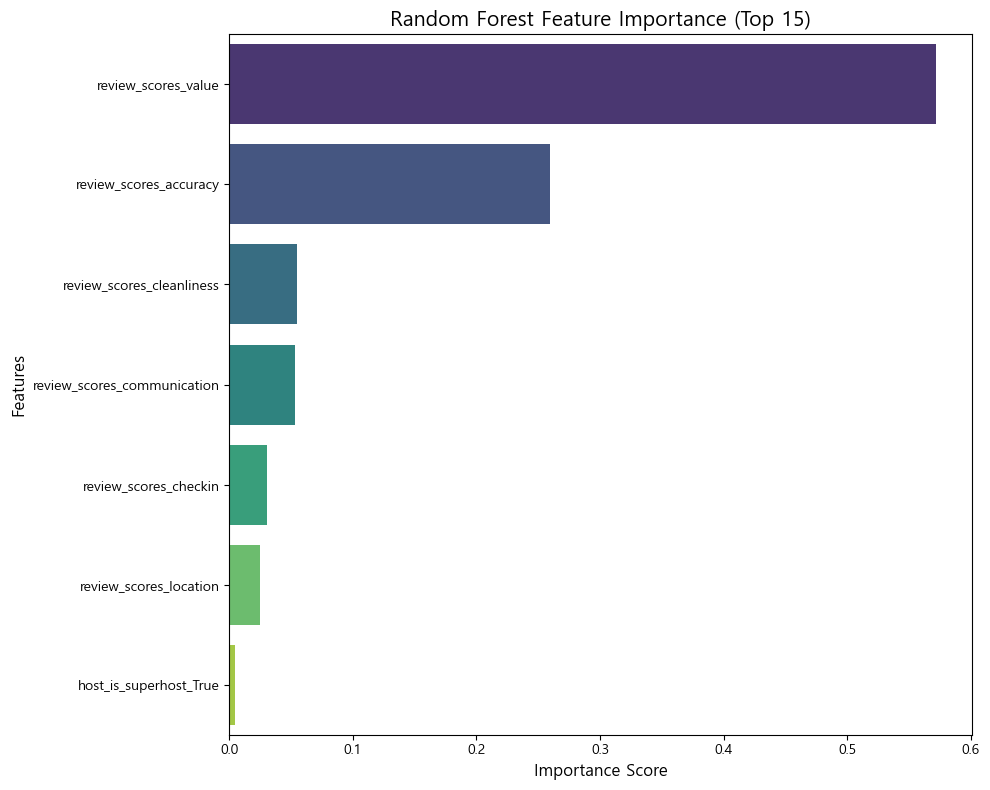

=== 특성 중요도 상위 10개 ===
                    Feature  Importance
        review_scores_value    0.572149
     review_scores_accuracy    0.259729
  review_scores_cleanliness    0.054907
review_scores_communication    0.052942
      review_scores_checkin    0.030376
     review_scores_location    0.024953
     host_is_superhost_True    0.004946


In [110]:
# 1. 모델이 계산한 특성 중요도(0~1 사이의 값)를 가져옵니다.
importances = rf_model.feature_importances_

# 2. X_train의 컬럼명(피처 이름)을 가져옵니다.
feature_names = X_train_dum.columns

# 3. 보기 편하게 '피처 이름'과 '중요도'를 짝지어서 데이터프레임으로 만듭니다.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. 중요도가 높은 순서대로(내림차순) 정렬합니다.
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. 시각화 (그래프 그리기)
plt.figure(figsize=(10, 8)) # 그래프 크기 설정
# 상위 15개의 피처만 뽑아서 수평 막대 그래프로 그립니다.
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')

plt.title('Random Forest Feature Importance (Top 15)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 6. 정확한 수치로도 상위 10개를 출력해 봅니다.
print("=== 특성 중요도 상위 10개 ===")
print(feature_importance_df.head(10).to_string(index=False))